# Hyperparameter Tuning

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

## Load Data

In [2]:
# 1. Carga del dataset original
df = pd.read_csv('data/house_pricing.csv')

# =========================================================================
# ¡NUEVA SECCIÓN!: INGENIERÍA DE CARACTERÍSTICAS (Para Labeled y Leaderboard)
# =========================================================================

# Creamos copias explícitas para evitar advertencias de pandas
df_fe = df.copy()

# A) Superficie Total de la Vivienda (Sótano + Planta Baja + Planta Alta)
df_fe['TotalSF'] = df_fe['TotalBsmtSF'].fillna(0) + df_fe['1stFlrSF'].fillna(0) + df_fe['2ndFlrSF'].fillna(0)
df_fe['TotalSF'] = df_fe['TotalBsmtSF'].fillna(0) + df_fe['1stFlrSF'].fillna(0) + df_fe['2ndFlrSF'].fillna(0)
# B) Antigüedad de la Casa al ser vendida (Asumiendo año base o estabilidad de fechas)
# Como no tenemos el año de venta exacto, usamos el año de remodelación/construcción para medir madurez
df_fe['HouseAge'] = 2026 - df_fe['YearBuilt']
df_fe['HouseAge'] = 2026 - df_fe['YearBuilt']
# C) Variable indicadora de si ha tenido reformas o actualizaciones
df_fe['IsRemodeled'] = (df_fe['YearRemodAdd'] > df_fe['YearBuilt']).astype(int)

# D) Total de Baños combinados de la propiedad
df_fe['TotalBathrooms'] = df_fe['FullBath'].fillna(0) + (df_fe['BsmtFullBath'].fillna(0) * 0.5)

# E) Proporción del área del garaje respecto al tamaño de la casa
df_fe['GarageToHouseRatio'] = df_fe['GarageArea'].fillna(0) / (df_fe['TotalSF'] + 1)

In [3]:
df_fe.shape

(992, 42)

## Train / Test

In [4]:
# 1. Filtramos las filas destinadas al entrenamiento local
df_labeled = df_fe[df_fe['Split'] == 'labeled'].copy()
df_labeled = df_labeled.dropna(subset=['SalePrice'])

# 2. Volvemos a dólares reales directamente para evitar el conflicto con el Scoring del Tuning
X = df_labeled.drop(columns=['SalePrice', 'Id', 'Split', 'Electtrical'], errors='ignore')
y = df_labeled['SalePrice']  # <--- DIRECTO EN DÓLARES

# 3. Homogeneizar tipos de variables de texto a categorías nativas
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# 4. Partición del dataset (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

## Feature Engineering

Defineix els passos de preprocessament per als models que ho necessiten.

In [5]:
# Mapeo de nuevas y viejas columnas categóricas y numéricas
categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

## Cross-validation

In [6]:
# Definición de la estrategia común de validación cruzada (10 Folds)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

Dummy Regressor (Baseline de Referencia)

In [7]:
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dummy', DummyRegressor(strategy='mean'))
])

dummy_cv = cross_validate(dummy_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)

print('CV Train MAE:', -dummy_cv['train_score'].mean().round(2))
print('CV Validation MAE:', -dummy_cv['test_score'].mean().round(2))

CV Train MAE: 39442.29
CV Validation MAE: 39501.44


LR: Linear Regresion

In [8]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

lr_cv = cross_validate(lr_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)

print('CV Train MAE:', -lr_cv['train_score'].mean().round(2))
print('CV Validation MAE:', -lr_cv['test_score'].mean().round(2))

CV Train MAE: 11549.98
CV Validation MAE: 13285.4


## Decision Tree

If this was not a pipeline, there would be no need to set `'dt__'` before hyperparameter names.

In [9]:
# Random Forest (Normal)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

rf_cv = cross_validate(rf_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)

print('CV Train MAE:', -rf_cv['train_score'].mean().round(2))
print('CV Validation MAE:', -rf_cv['test_score'].mean().round(2))

CV Train MAE: 3955.24
CV Validation MAE: 10714.08


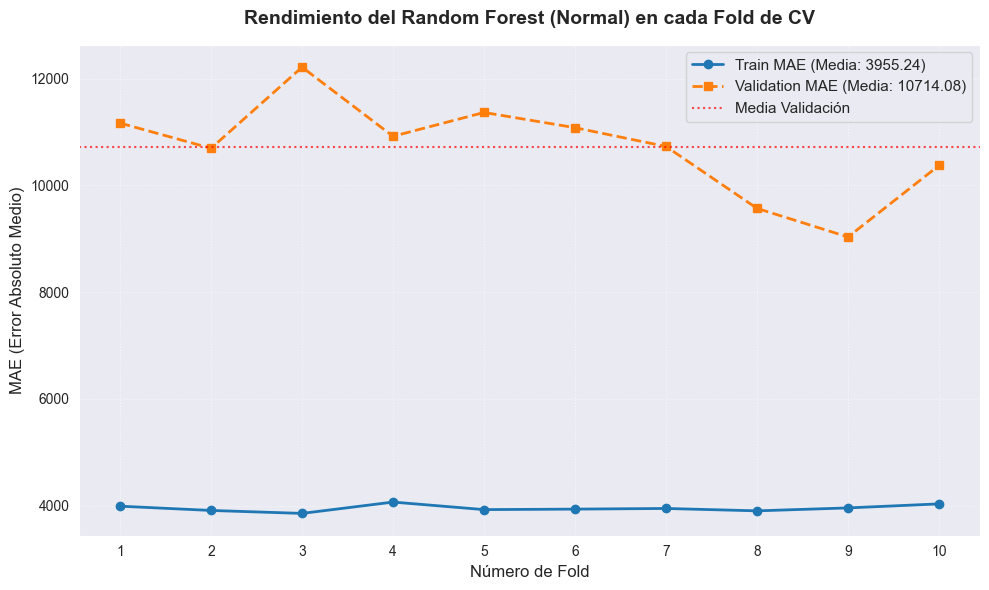

In [10]:
#Gráfica

# 1. Extraer los scores de cada fold y convertirlos a MAE positivo
train_mae_scores = -rf_cv['train_score']
val_mae_scores = -rf_cv['test_score']
folds = range(1, len(train_mae_scores) + 1)

# 2. Configurar el tamaño de la gráfica
plt.figure(figsize=(10, 6))

# 3. Graficar las líneas de Train y Validation fold por fold
plt.plot(folds, train_mae_scores, color='#1f77b4', marker='o', linestyle='-', linewidth=2, label=f'Train MAE (Media: {train_mae_scores.mean().round(2)})')
plt.plot(folds, val_mae_scores, color='#ff7f0e', marker='s', linestyle='--', linewidth=2, label=f'Validation MAE (Media: {val_mae_scores.mean().round(2)})')

# 4. Personalizar ejes, título y cuadrícula
plt.title('Rendimiento del Random Forest (Normal) en cada Fold de CV', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Fold', fontsize=12)
plt.ylabel('MAE (Error Absoluto Medio)', fontsize=12)
plt.xticks(folds)  # Asegura que se muestren los números del 1 al 10

# Añadir una línea horizontal con la media de validación como referencia visual
plt.axhline(y=val_mae_scores.mean(), color='red', linestyle=':', alpha=0.7, label='Media Validación')

# Estilo de la leyenda y diseño limpio
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# 5. Mostrar la gráfica en tu notebook
plt.show()

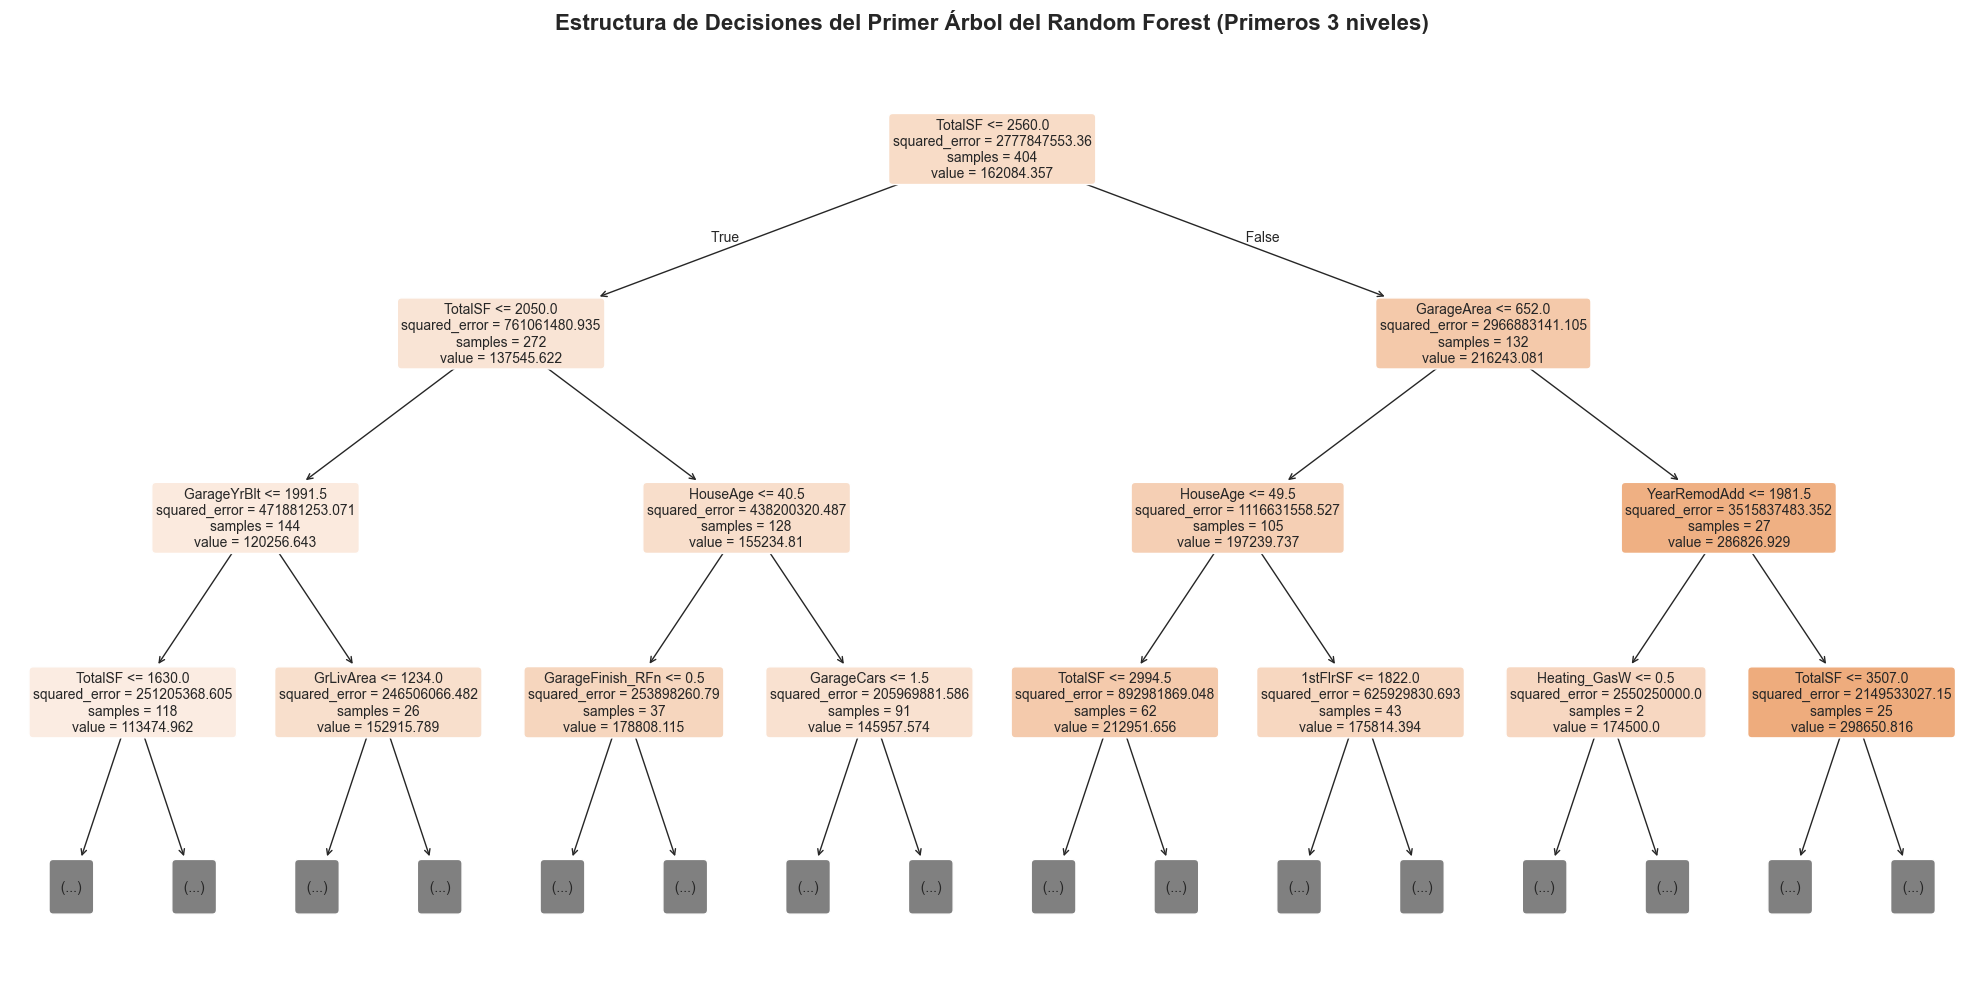

--- ANÁLISIS ESTRUCTURAL DEL BOSQUE ---
Número de árboles en el bosque: 100
Promedio de nudos totales por árbol: 763
Promedio de hojas (predicciones finales) por árbol: 382
Árbol más grande: 795 nudos | Árbol más pequeño: 733 nudos


In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Entrenamos el pipeline una vez fuera de CV para poder extraer los árboles reales
rf_pipeline.fit(X_train, y_train)

# Extraemos el modelo Random Forest y el preprocesador del Pipeline
rf_model = rf_pipeline.named_steps['rf']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Extraemos los nombres de las columnas transformadas (para saber qué variable divide cada nudo)
# Combinamos los nombres de variables numéricas y las categóricas tras el OneHotEncoder
encoded_cat_features = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
all_features_names = numeric_features + encoded_cat_features

# =========================================================================
# PARTE 1: Graficar los primeros niveles de un árbol individual del bosque
# =========================================================================
plt.figure(figsize=(20, 10))

# Tomamos el primer árbol del bosque (estimador 0)
# max_depth=3 limita la visualización a los primeros niveles para que sea legible
plot_tree(
    rf_model.estimators_[0],
    max_depth=3,
    feature_names=all_features_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Estructura de Decisiones del Primer Árbol del Random Forest (Primeros 3 niveles)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =========================================================================
# PARTE 2: Calcular el número real de nudos y hojas de todo el bosque
# =========================================================================
# Extraemos el número de nudos de división y hojas finales de cada uno de los árboles
n_nodes = [estimator.tree_.node_count for estimator in rf_model.estimators_]
n_leaves = [estimator.tree_.n_leaves for estimator in rf_model.estimators_]

print("--- ANÁLISIS ESTRUCTURAL DEL BOSQUE ---")
print(f"Número de árboles en el bosque: {len(rf_model.estimators_)}")
print(f"Promedio de nudos totales por árbol: {int(np.mean(n_nodes))}")
print(f"Promedio de hojas (predicciones finales) por árbol: {int(np.mean(n_leaves))}")
print(f"Árbol más grande: {max(n_nodes)} nudos | Árbol más pequeño: {min(n_nodes)} nudos")

In [12]:
# HistGradient Boosting (Normal)

# Funciona directo sobre el dataframe sin pasar por el preprocesor (OneHotEncoder)
gb = HistGradientBoostingRegressor(categorical_features='from_dtype', random_state=42)

gb_cv = cross_validate(gb, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', return_train_score=True, n_jobs=-1)

print('CV Train MAE:', -gb_cv['train_score'].mean().round(2))
print('CV Validation MAE:', -gb_cv['test_score'].mean().round(2))

CV Train MAE: 3259.28
CV Validation MAE: 10023.03


### Randomized Search

With a Decistion Tree.

As we're performing a randomized search, we can try wider ranges of hyperparameter values.

#### Round 1

In [13]:
# Random Forest (Tuned)

rf_param_dist = {
    'rf__n_estimators': [50, 100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30, 40],
    'rf__min_samples_split': range(2, 11),
    'rf__min_samples_leaf': range(1, 11),
    'rf__max_features': ['sqrt', 'log2', None]
}

rf_rs = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    cv=kf,
    random_state=42,
    n_jobs=-1
)
rf_rs.fit(X_train, y_train)

print('Best RandomizedSearchCV parameters:', rf_rs.best_params_)
print('CV Train MAE:', -rf_rs.cv_results_['mean_train_score'][rf_rs.best_index_].round(2))
print('CV Validation MAE:', -rf_rs.cv_results_['mean_test_score'][rf_rs.best_index_].round(2))

Best RandomizedSearchCV parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 10}
CV Train MAE: 4961.71
CV Validation MAE: 10394.03


#### Round 2

In [14]:
gb_model = HistGradientBoostingRegressor(categorical_features='from_dtype', random_state=42)

# Ajustamos los rangos para estabilizar el comportamiento en dólares reales
gb_param_dist = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_iter': [100, 150, 200],
    'max_depth': range(3, 12),              # Árboles un poco más cortos evitan errores gigantes
    'min_samples_leaf': range(15, 31),
    'l2_regularization': [0.1, 1.0, 10.0]   # Regularización más fuerte para mitigar outliers
}

gb_rs = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    cv=kf,
    random_state=42,
    n_jobs=-1
)

gb_rs.fit(X_train, y_train)

# Evaluación local directa (Ya no hace falta np.expm1)
preds_test_real = gb_rs.predict(X_test)
mae_local = mean_absolute_error(y_test, preds_test_real)

print('--- MEJORAS APLICADAS CON ÉXITO ---')
print('Mejores parámetros optimizados:', gb_rs.best_params_)
print(f'MAE de Validación estimado en tu Local Test Set: ${round(mae_local, 2)}')

--- MEJORAS APLICADAS CON ÉXITO ---
Mejores parámetros optimizados: {'min_samples_leaf': 19, 'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 1.0}
MAE de Validación estimado en tu Local Test Set: $11631.25


**Comparación Final de Modelos**

In [16]:
resultados = pd.DataFrame({
    'Model': [
        'Dummy',
        'Linear Regression',
        'Random Forest (Base)',
        'HistGradient Boosting (Base)',
        'Random Forest (Tuned)',
        'HistGradient Boosting (Tuned)'
    ],
    'Validation MAE': [
        -dummy_cv['test_score'].mean().round(2),
        -lr_cv['test_score'].mean().round(2),
        -rf_cv['test_score'].mean().round(2),
        -gb_cv['test_score'].mean().round(2),
        -rf_rs.cv_results_['mean_test_score'][rf_rs.best_index_].round(2),
        -gb_rs.cv_results_['mean_test_score'][gb_rs.best_index_].round(2)
    ]
})

print(resultados.to_string(index=False))

                        Model  Validation MAE
                        Dummy        39501.44
            Linear Regression        13285.40
         Random Forest (Base)        10714.08
 HistGradient Boosting (Base)        10023.03
        Random Forest (Tuned)        10394.03
HistGradient Boosting (Tuned)         9754.17


Creando el fichero con LeaderBorad

In [17]:
# 1. Extraemos las filas del leaderboard que ya pasaron por el Feature Engineering inicial
df_leaderboard = df_fe[df_fe['Split'] == 'leaderboard'].copy()

# 2. Construimos la matriz de predicción idéntica a X_train
X_leaderboard = df_leaderboard.drop(columns=['SalePrice', 'Id', 'Split', 'Electtrical'], errors='ignore')

# 3. Transformación de dtypes
for col in X_leaderboard.select_dtypes(include=['object']).columns:
    X_leaderboard[col] = X_leaderboard[col].astype('category')

# 4. El modelo predice directamente en dólares reales
predicciones_reales = gb_rs.predict(X_leaderboard)

# 5. Guardamos el archivo final con la columna 'prediction' exigida por la plataforma
submission_df = pd.DataFrame({
    'Id': df_leaderboard['Id'],
    'prediction': predicciones_reales.round(2)
})

submission_df.to_csv('house_pricing_predictions_levi_2.csv', index=False)
print("--- NUEVO ARCHIVO DE ENTREGAS GENERADO CORREGIDO ---")
print(submission_df.head())

--- NUEVO ARCHIVO DE ENTREGAS GENERADO CORREGIDO ---
      Id  prediction
794  795   217619.04
795  796    98580.07
796  797   214897.06
797  798   111946.21
798  799   243666.91
